# 3. Datareduktion
PCA, t-SNE och UMAP (extra) på WHR26-features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from pathlib import Path

_here = Path().resolve()
DATA_DIR = _here / 'data' if (_here / 'data').exists() else _here.parent / 'data'

df = pd.read_csv(DATA_DIR / 'cleaned_data.csv')

FEATURE_COLS = ['gdp', 'social_support', 'health', 'freedom', 'generosity', 'corruption', 'dystopia_residual']

df_latest = df[df['Year'] == df['Year'].max()].dropna(subset=FEATURE_COLS).copy()

X = df_latest[FEATURE_COLS].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Arbetar med {len(df_latest)} länder, år {df_latest["Year"].iloc[0]}')

Arbetar med 145 länder, år 2025


## PCA

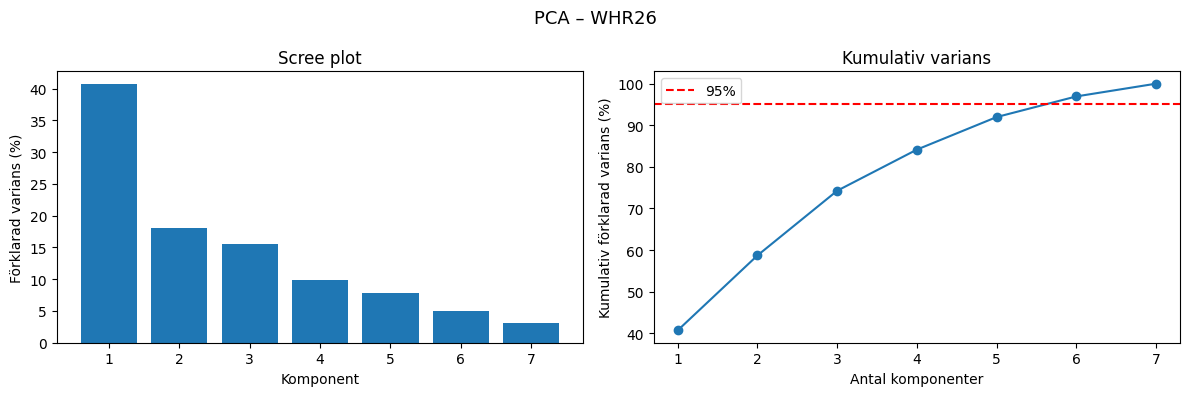

PC1: 40.7%  (kumulativt: 40.7%)
PC2: 18.0%  (kumulativt: 58.7%)
PC3: 15.6%  (kumulativt: 74.2%)
PC4: 9.9%  (kumulativt: 84.1%)
PC5: 7.8%  (kumulativt: 92.0%)
PC6: 5.0%  (kumulativt: 96.9%)
PC7: 3.1%  (kumulativt: 100.0%)


In [2]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained = np.cumsum(pca_full.explained_variance_ratio_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_ * 100)
ax1.set_xlabel('Komponent')
ax1.set_ylabel('Förklarad varians (%)')
ax1.set_title('Scree plot')

ax2.plot(range(1, len(explained) + 1), explained * 100, marker='o')
ax2.axhline(95, color='r', linestyle='--', label='95%')
ax2.set_xlabel('Antal komponenter')
ax2.set_ylabel('Kumulativ förklarad varians (%)')
ax2.set_title('Kumulativ varians')
ax2.legend()

plt.suptitle('PCA – WHR26', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / 'pca_scree.png', dpi=150)
plt.show()

for i, r in enumerate(pca_full.explained_variance_ratio_):
    print(f'PC{i+1}: {r*100:.1f}%  (kumulativt: {explained[i]*100:.1f}%)')

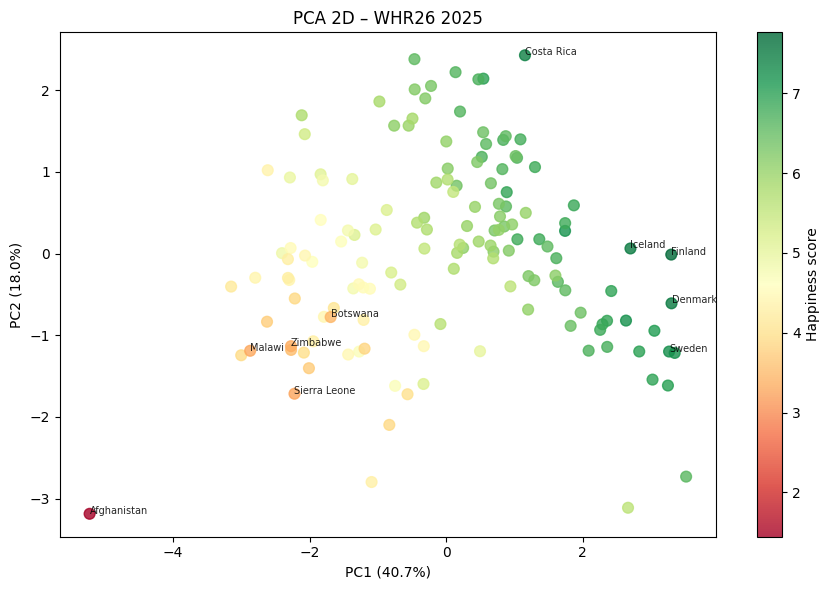

In [3]:
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled)
df_latest = df_latest.copy()
df_latest['PC1'] = X_pca[:, 0]
df_latest['PC2'] = X_pca[:, 1]

plt.figure(figsize=(9, 6))
sc = plt.scatter(df_latest['PC1'], df_latest['PC2'],
                 c=df_latest['happiness_score'], cmap='RdYlGn', s=60, alpha=0.8)
plt.colorbar(sc, label='Happiness score')

for _, row in pd.concat([df_latest.nsmallest(5, 'Rank'), df_latest.nlargest(5, 'Rank')]).iterrows():
    plt.annotate(row['country'], (row['PC1'], row['PC2']), fontsize=7, alpha=0.85)

plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'PCA 2D – WHR26 {df_latest["Year"].iloc[0]}')
plt.tight_layout()
plt.savefig(DATA_DIR / 'pca_2d.png', dpi=150)
plt.show()

Loadings:
                     PC1    PC2
gdp                0.511  0.012
health             0.495 -0.163
social_support     0.470  0.260
freedom            0.376  0.282
corruption         0.358 -0.374
generosity         0.058 -0.390
dystopia_residual  0.004  0.730


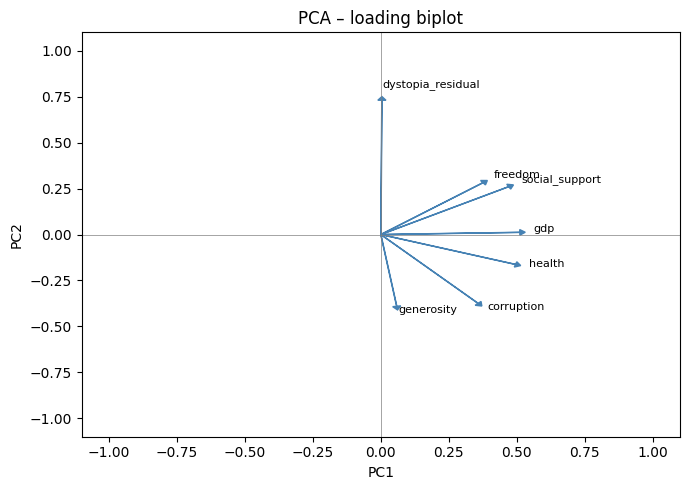

In [4]:
loadings = pd.DataFrame(
    pca2.components_.T,
    index=FEATURE_COLS,
    columns=['PC1', 'PC2']
).round(3)
print('Loadings:')
print(loadings.sort_values('PC1', ascending=False))

fig, ax = plt.subplots(figsize=(7, 5))
for i, feat in enumerate(FEATURE_COLS):
    ax.arrow(0, 0, pca2.components_[0, i], pca2.components_[1, i],
             head_width=0.03, head_length=0.02, fc='steelblue', ec='steelblue')
    ax.text(pca2.components_[0, i] * 1.1, pca2.components_[1, i] * 1.1,
            feat, fontsize=8)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA – loading biplot')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.savefig(DATA_DIR / 'pca_biplot.png', dpi=150)
plt.show()

## t-SNE

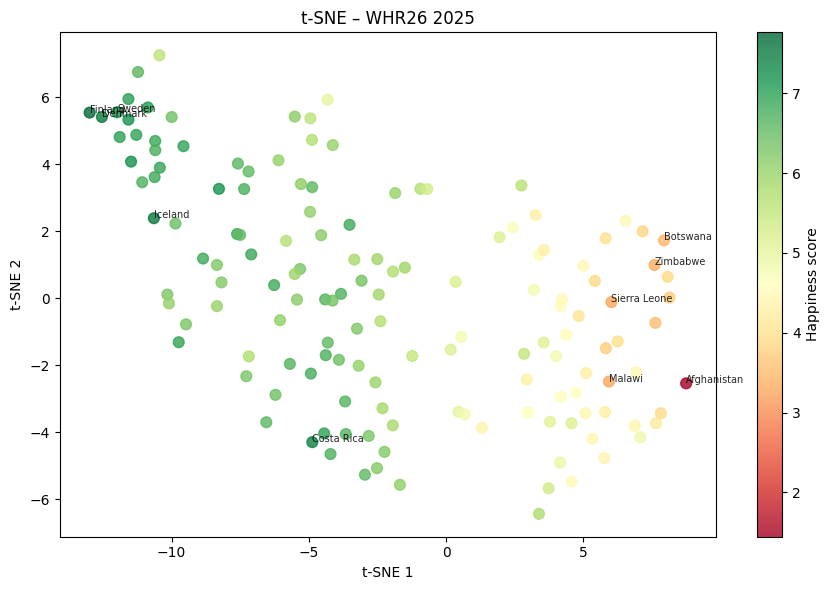

In [5]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
df_latest['tSNE1'] = X_tsne[:, 0]
df_latest['tSNE2'] = X_tsne[:, 1]

plt.figure(figsize=(9, 6))
sc = plt.scatter(df_latest['tSNE1'], df_latest['tSNE2'],
                 c=df_latest['happiness_score'], cmap='RdYlGn', s=60, alpha=0.8)
plt.colorbar(sc, label='Happiness score')

for _, row in pd.concat([df_latest.nsmallest(5, 'Rank'), df_latest.nlargest(5, 'Rank')]).iterrows():
    plt.annotate(row['country'], (row['tSNE1'], row['tSNE2']), fontsize=7, alpha=0.85)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title(f't-SNE – WHR26 {df_latest["Year"].iloc[0]}')
plt.tight_layout()
plt.savefig(DATA_DIR / 'tsne_2d.png', dpi=150)
plt.show()

## UMAP – hyperparameter-justering (EXTRA)

C:\Users\anton\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\anton\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\anton\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\anton\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\anton\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\anton\AppData\Roaming\Python\Python314\site-package

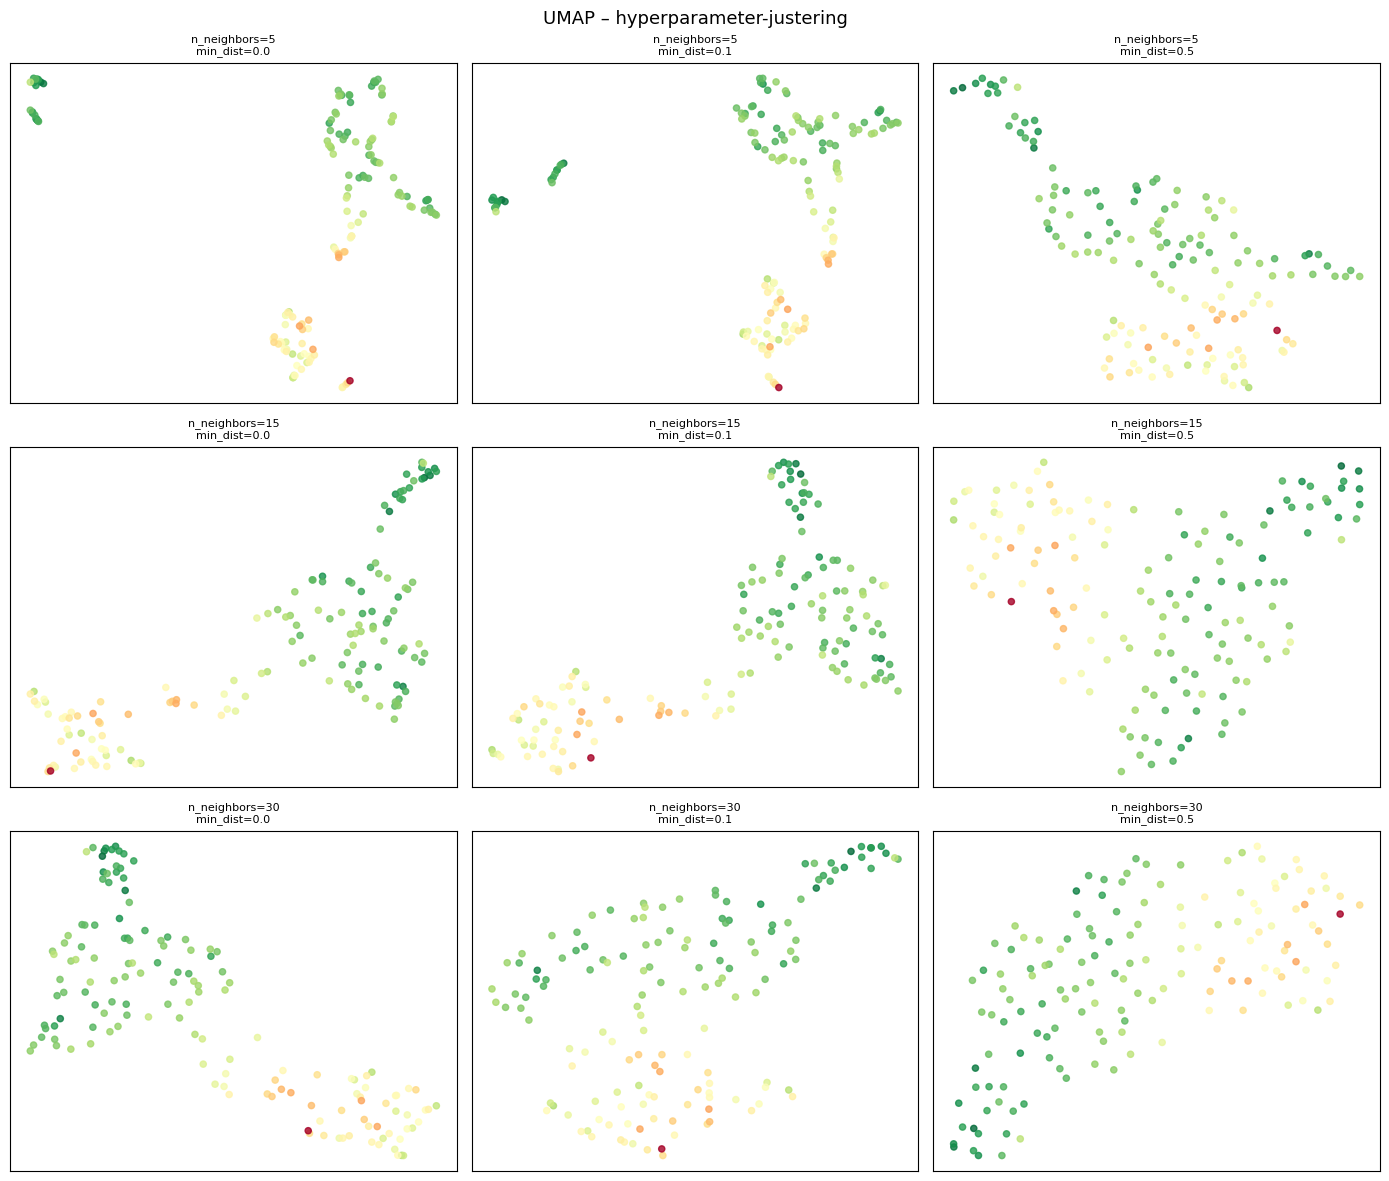

In [6]:
try:
    import umap
except ImportError:
    print('Installera med: pip install umap-learn')
    raise

n_neighbors_list = [5, 15, 30]
min_dist_list = [0.0, 0.1, 0.5]

fig, axes = plt.subplots(len(n_neighbors_list), len(min_dist_list), figsize=(14, 12))

for i, n_neighbors in enumerate(n_neighbors_list):
    for j, min_dist in enumerate(min_dist_list):
        reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, random_state=42)
        X_umap = reducer.fit_transform(X_scaled)
        ax = axes[i][j]
        ax.scatter(X_umap[:, 0], X_umap[:, 1],
                   c=df_latest['happiness_score'], cmap='RdYlGn', s=20, alpha=0.8)
        ax.set_title(f'n_neighbors={n_neighbors}\nmin_dist={min_dist}', fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle('UMAP – hyperparameter-justering', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / 'umap_hyperparam.png', dpi=150)
plt.show()